# Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import ctypes

from numpy import dtype

lib = ctypes.cdll.LoadLibrary('../lib_classification/target/release/lib_classification.dll')

class MyDroite(ctypes.Structure):_fields_ = [
    ("a", ctypes.c_float),
    ("b", ctypes.c_float),
    ("c", ctypes.c_float),
]

lib.initialisation_droite.restype = ctypes.POINTER(MyDroite)
lib.training.restype = ctypes.POINTER(MyDroite)
lib.linear_classification_prediction.restype = ctypes.c_int8
lib.linear_classification_prediction.argtypes = [
        ctypes.c_float,
        ctypes.c_float,
        ctypes.c_float,
        ctypes.c_float,
        ctypes.c_float,
        ctypes.c_float
    ]

# Cas de tests, rendu 2

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [135]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
], dtype=np.float32)
Y = np.array([
      1,
      -1,
      -1
], dtype=np.int8)


ma_droite = lib.initialisation_droite()
a = ma_droite.contents.a
b = ma_droite.contents.b
c = ma_droite.contents.c
w = MyDroite(a, b, c)

In [136]:
data_ptr = X.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

labels_ptr = Y.ctypes.data_as(ctypes.POINTER(ctypes.c_int8))

In [137]:

w = lib.training(ctypes.c_float(0.001), 100, len(X), w, data_ptr, labels_ptr)
w = w.contents

print(w.a)
print(w.b)
print(w.c)


-0.0003996260929852724
-0.3037005066871643
0.2507428824901581


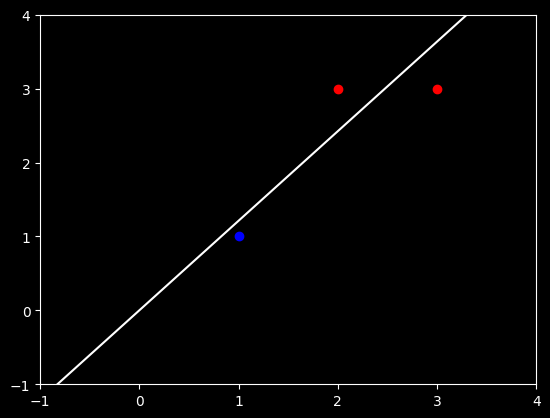

0 -1 1
1 1 -1
2 -1 -1


<Figure size 640x480 with 0 Axes>

In [141]:
x_vals = np.linspace(-1, 4, 100)
y_vals = -(w.a + w.b * x_vals) / w.c

plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.plot(x_vals, y_vals, color='white')
plt.xlim(-1, 4)
plt.ylim(-1, 4)
plt.show()
plt.clf()

for i in range(len(X)):
    pred = lib.linear_classification_prediction(w.a, w.b, w.c,1.0, X[i][0], X[i][1])
    print(i, pred, Y[i])

### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [142]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])], dtype=np.float32)
Y = np.concatenate([np.ones((50,1), dtype=np.int8), np.ones((50,1), dtype=np.int8) * -1.0])


In [143]:
ma_droite1 = lib.initialisation_droite()
a = ma_droite1.contents.a
b = ma_droite1.contents.b
c = ma_droite1.contents.c
w1 = MyDroite(a, b, c)

data_ptr = X.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

labels_ptr = Y.ctypes.data_as(ctypes.POINTER(ctypes.c_int8))
#labels_ptr = Y.flatten().ctypes.data_as(ctypes.POINTER(ctypes.c_int8))

In [167]:
w1 = lib.training(ctypes.c_float(0.000001), 10000, len(X), w1, data_ptr, labels_ptr)
w1 = w1.contents
print(w1.a, w1.b, w1.c)





1.5591374635696411 1.8849103450775146 2.0776736736297607


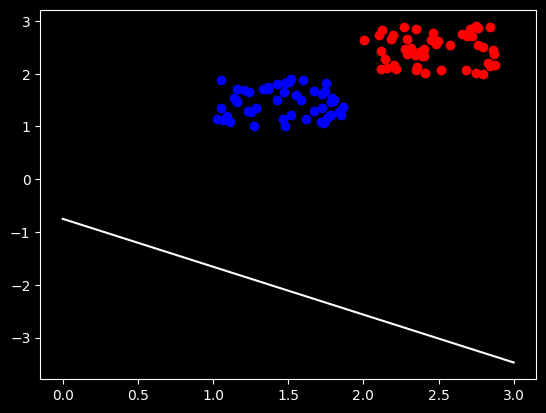

0 1 [1.]
1 1 [1.]
2 1 [1.]
3 1 [1.]
4 1 [1.]
5 1 [1.]
6 1 [1.]
7 1 [1.]
8 1 [1.]
9 1 [1.]
10 1 [1.]
11 1 [1.]
12 1 [1.]
13 1 [1.]
14 1 [1.]
15 1 [1.]
16 1 [1.]
17 1 [1.]
18 1 [1.]
19 1 [1.]
20 1 [1.]
21 1 [1.]
22 1 [1.]
23 1 [1.]
24 1 [1.]
25 1 [1.]
26 1 [1.]
27 1 [1.]
28 1 [1.]
29 1 [1.]
30 1 [1.]
31 1 [1.]
32 1 [1.]
33 1 [1.]
34 1 [1.]
35 1 [1.]
36 1 [1.]
37 1 [1.]
38 1 [1.]
39 1 [1.]
40 1 [1.]
41 1 [1.]
42 1 [1.]
43 1 [1.]
44 1 [1.]
45 1 [1.]
46 1 [1.]
47 1 [1.]
48 1 [1.]
49 1 [1.]
50 1 [-1.]
51 1 [-1.]
52 1 [-1.]
53 1 [-1.]
54 1 [-1.]
55 1 [-1.]
56 1 [-1.]
57 1 [-1.]
58 1 [-1.]
59 1 [-1.]
60 1 [-1.]
61 1 [-1.]
62 1 [-1.]
63 1 [-1.]
64 1 [-1.]
65 1 [-1.]
66 1 [-1.]
67 1 [-1.]
68 1 [-1.]
69 1 [-1.]
70 1 [-1.]
71 1 [-1.]
72 1 [-1.]
73 1 [-1.]
74 1 [-1.]
75 1 [-1.]
76 1 [-1.]
77 1 [-1.]
78 1 [-1.]
79 1 [-1.]
80 1 [-1.]
81 1 [-1.]
82 1 [-1.]
83 1 [-1.]
84 1 [-1.]
85 1 [-1.]
86 1 [-1.]
87 1 [-1.]
88 1 [-1.]
89 1 [-1.]
90 1 [-1.]
91 1 [-1.]
92 1 [-1.]
93 1 [-1.]
94 1 [-1.]
95 1 [-1.]
96 1

<Figure size 640x480 with 0 Axes>

In [168]:
x_vals = np.linspace(0, 3, 100)
y1_vals = -(w1.a + w1.b * x_vals) / w1.c


plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.plot(x_vals, y1_vals, color='white')
#plt.xlim(0.9, 3.1)
#plt.ylim(0.9, 3.1)
plt.show()
plt.clf()

for i in range(len(X)):
    pred = lib.linear_classification_prediction(w1.a, w1.b, w1.c,1.0, X[i][0], X[i][1])
    print(i, pred, Y[i])

correct = 0

for i in range(len(X)):
    pred = lib.linear_classification_prediction(
        w1.a, w1.b, w1.c,
        1.0, X[i][0], X[i][1]
    )

    if pred == Y[i]:
        correct += 1

print("score:", correct, "/", len(X))

### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [222]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]], dtype=np.float32)
Y = np.array([1, 1, -1, -1], dtype=np.int8)

ma_droite = lib.initialisation_droite()
a = ma_droite.contents.a
b = ma_droite.contents.b
c = ma_droite.contents.c
w = MyDroite(a, b, c)

ma_droite1 = lib.initialisation_droite()
a = ma_droite1.contents.a
b = ma_droite1.contents.b
c = ma_droite1.contents.c
w1 = MyDroite(a, b, c)

In [223]:
data_ptr = X.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

labels_ptr = Y.ctypes.data_as(ctypes.POINTER(ctypes.c_int8))

In [224]:
w = lib.training(ctypes.c_float(0.001), 1000, 4, w, data_ptr, labels_ptr)
w = w.contents

w1 = lib.training(ctypes.c_float(0.001), 1000, 4, w1, data_ptr, labels_ptr)
w1 = w1.contents

print(w.a)
print(w.b)
print(w.c)
print(" ")
print(w1.a)
print(w1.b)
print(w1.c)


-0.006697590462863445
-0.008104253560304642
0.157589852809906
 
0.054881975054740906
-0.05328960344195366
-0.05554107576608658


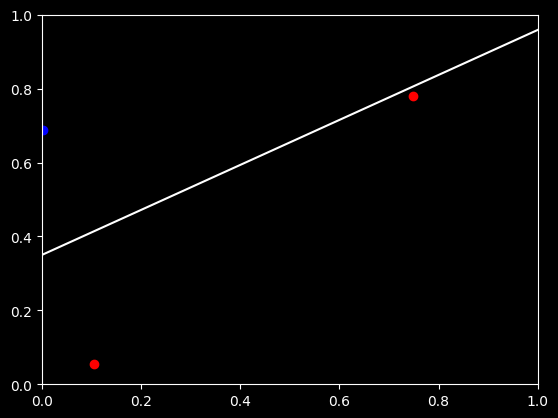

<Figure size 640x480 with 0 Axes>

In [173]:
x_vals = np.linspace(0, 1, 100)
y_vals = -(w.a + w.b * x_vals) / w.c
y1_vals = -(w1.a + w1.b * x_vals) / w1.c

plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.plot(x_vals, y_vals, color='white')
plt.plot(x_vals, y1_vals, color='white')
plt.xlim(-0, 1)
plt.ylim(-0, 1)
plt.show()
plt.clf()

























































































### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [538]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

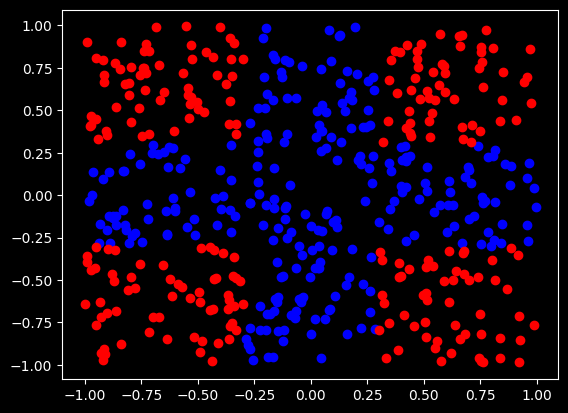

<Figure size 640x480 with 0 Axes>

In [539]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [169]:
X = np.random.random((500, 2)).astype(np.float32) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X], dtype=np.int8)

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]


ma_droite = lib.initialisation_droite()
a = ma_droite.contents.a
b = ma_droite.contents.b
c = ma_droite.contents.c
w = MyDroite(a, b, c)

ma_droite = lib.initialisation_droite()
a = ma_droite.contents.a
b = ma_droite.contents.b
c = ma_droite.contents.c
w1 = MyDroite(a, b, c)

ma_droite = lib.initialisation_droite()
a = ma_droite.contents.a
b = ma_droite.contents.b
c = ma_droite.contents.c
w2 = MyDroite(a, b, c)

In [170]:
data_ptr = X.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

labels_ptr = Y.ctypes.data_as(ctypes.POINTER(ctypes.c_int8))

In [264]:
w = lib.training(ctypes.c_float(0.00001), 1000000, len(X), w, data_ptr, labels_ptr)
w = w.contents

w1 = lib.training(ctypes.c_float(0.00001), 1000000, len(X), w1, data_ptr, labels_ptr)
w1 = w1.contents

w2 = lib.training(ctypes.c_float(0.00001), 1000000, len(X), w2, data_ptr, labels_ptr)
w2 = w2.contents


print(w.a, w.b, w.c)
print(w1.a, w1.b, w1.c)
print(w2.a, w2.b, w2.c)

-5.346526450011879e-06 -1.1737196473404765e-05 -8.279779649456032e-06
-2.3112610506359488e-05 8.860652087605558e-06 1.5785222785780206e-05
-8.052054909057915e-06 9.522973414277658e-07 9.109207894653082e-06


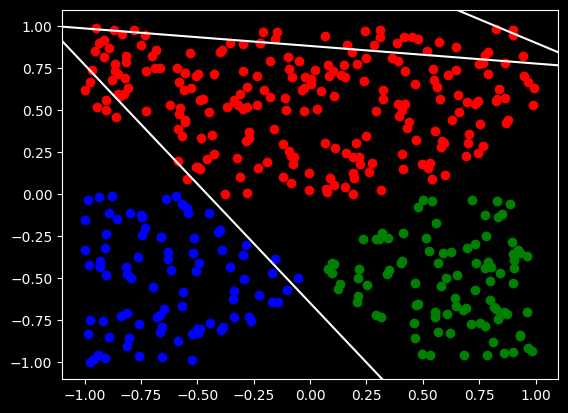

<Figure size 640x480 with 0 Axes>

In [265]:
x_vals = np.linspace(-1.1, 1.1, 100)
y_vals = -(w.a + w.b * x_vals) / w.c

y1_vals = -(w1.a + w1.b * x_vals) / w1.c

y2_vals = -(w2.a + w2.b * x_vals) / w2.c

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')

plt.plot(x_vals, y_vals, color='white')
plt.plot(x_vals, y1_vals, color='white')
plt.plot(x_vals, y2_vals, color='white')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.show()
plt.clf()

### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

In [43]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

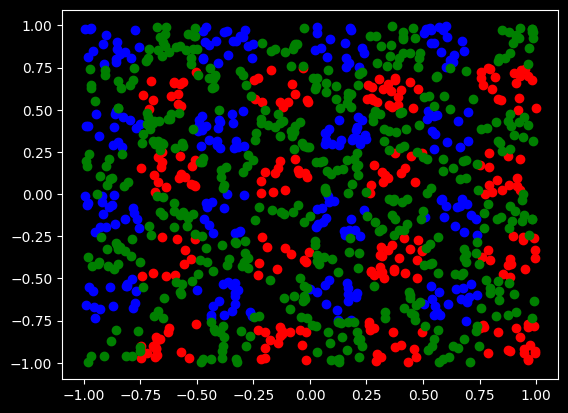

<Figure size 640x480 with 0 Axes>

In [44]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

In [45]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

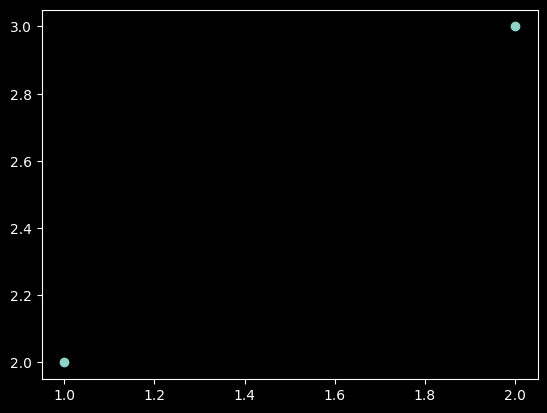

<Figure size 640x480 with 0 Axes>

In [46]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

In [47]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

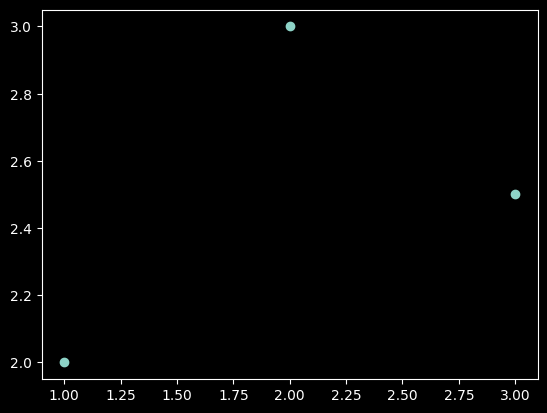

<Figure size 640x480 with 0 Axes>

In [48]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [49]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

In [50]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [51]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

In [52]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [53]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

In [54]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>